# Advance Statistics Lab: Decision Tree Implementation
## Dataset: Titanic - Machine Learning from Disaster

**Objective:** The goal of this project is to build a Decision Tree classifier to predict whether a passenger survived or not based on features like age, sex, and passenger class. We will focus on data preprocessing, feature engineering, and model evaluation.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
# Make sure the file name matches exactly what you uploaded
df = pd.read_csv('Titanic-Dataset.csv')

# Display first 5 rows
print("Dataset successfully loaded!")
df.head()

Dataset successfully loaded!


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Preprocessing
In this step, we will:
1. Handle missing values (Age and Embarked).
2. Drop irrelevant columns (Name, Ticket, Cabin, PassengerId).
3. Encode categorical variables (Sex and Embarked) into numerical format.

In [25]:
# 1. Check for missing values
print("Missing values before cleaning:\n", df.isnull().sum())


df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print("\nData Preprocessing complete. Missing values now:", df.isnull().sum().sum())
df.head()

Missing values before cleaning:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Data Preprocessing complete. Missing values now: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


## Data Splitting
We split the data into a **Training Set** (80%) to train our model and a **Test Set** (20%) to evaluate its performance on unseen data.

In [26]:
# Features (X) & Target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {X_train.shape[0]}, Testing rows: {X_test.shape[0]}")

Training rows: 712, Testing rows: 179


## Decision Tree Model Training
We are using the `DecisionTreeClassifier` with `entropy` as the selection criterion to build our model.

In [27]:
# Creating Decision Tree model
# Preventing from Tree complexity we selected dept - 3
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=42
    )

# Model Training
model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


## Model Evaluation and Statistical Analysis
To evaluate the performance of our Decision Tree, we will use the following metrics:
1. **Accuracy Score:** The percentage of correct predictions.
2. **Confusion Matrix:** To see the distribution of True Positives and False Positives.
3. **Classification Report:** Detailed view of Precision, Recall, and F1-Score.

Model Accuracy: 79.89%


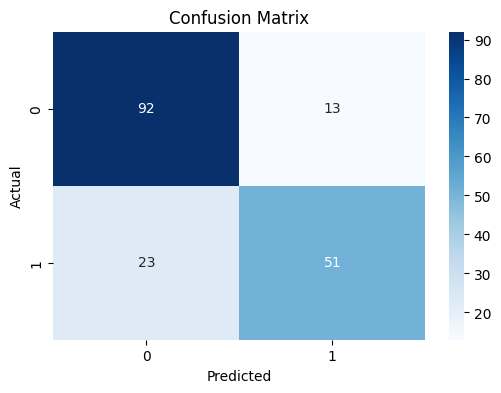


Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [28]:
# Making predictions on the test set
y_pred = model.predict(X_test)

# Calculating Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Plotting the Confusion Matrix for better understanding
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Displaying Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

## Visualizing the Decision Tree Logic
The following diagram shows the statistical splits made by the model.
- **Root Node:** The most important feature for splitting.
- **Gini/Entropy:** The measure of impurity at each node.

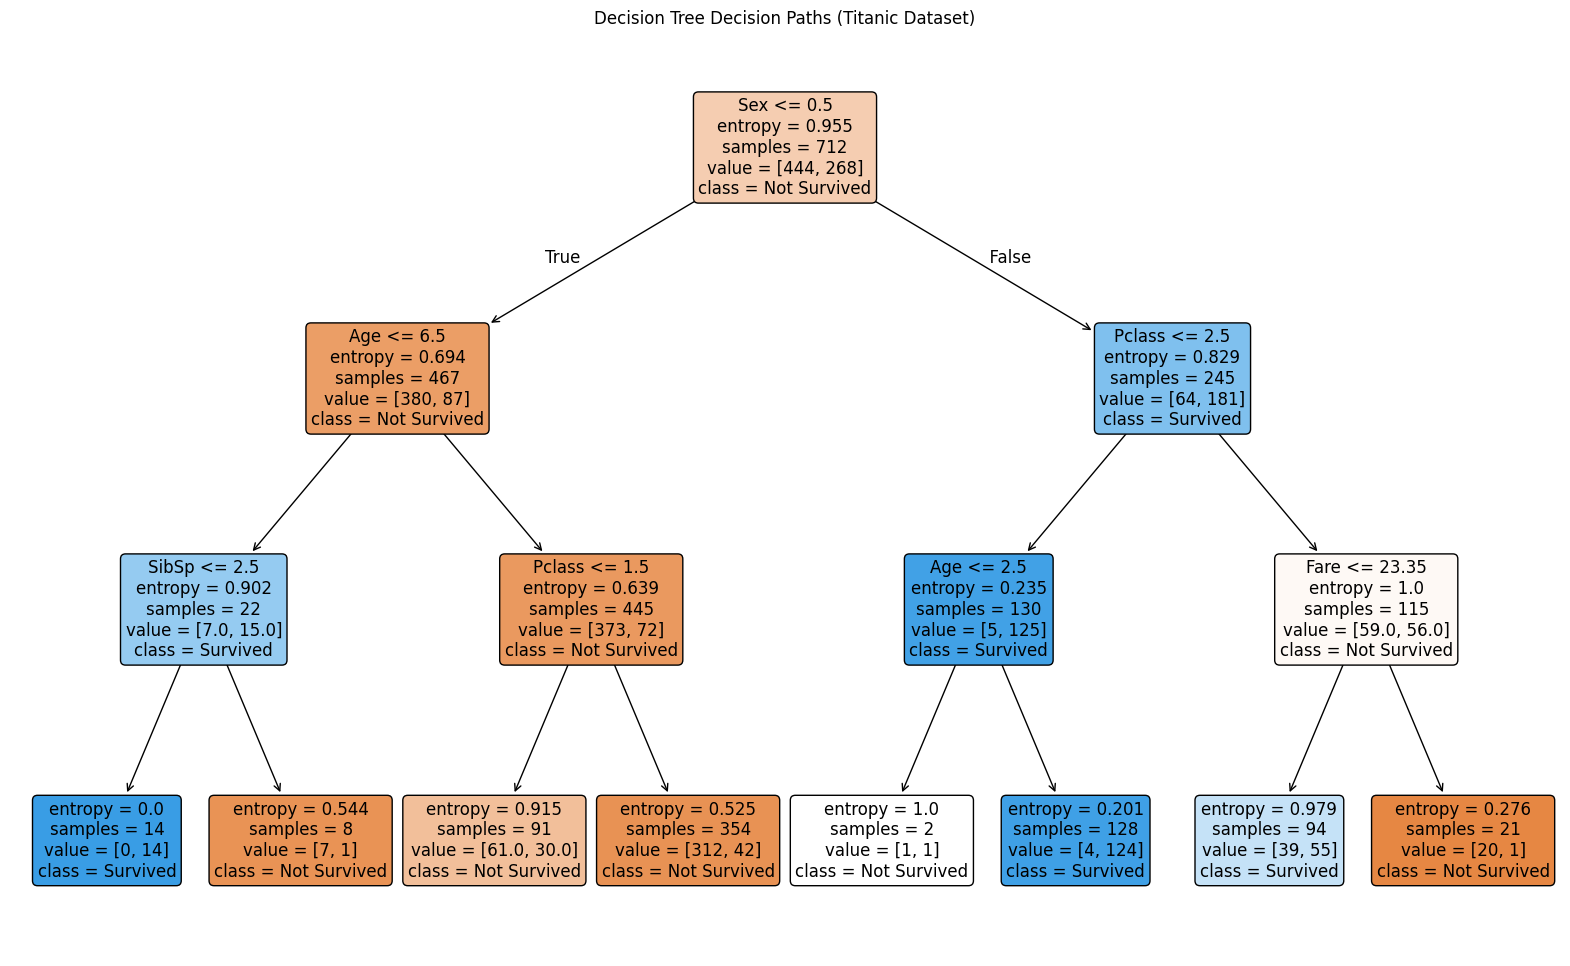

In [29]:
# Plotting the tree with proper features and class names
plt.figure(figsize=(20,12))
plot_tree(model,
          feature_names=X.columns,
          class_names=['Not Survived', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=12)
plt.title("Decision Tree Decision Paths (Titanic Dataset)")
plt.show()

## Step 8: Advanced Hyperparameter Tuning
To make the model more robust and 'Pro-level', we are tuning parameters like `min_samples_split` and increasing the `max_depth` to capture more complex patterns without overfitting.

In [30]:

advanced_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

advanced_model.fit(X_train, y_train)

# Check new accuracy
adv_acc = advanced_model.score(X_test, y_test)
print(f"Advanced Model Accuracy: {adv_acc * 100:.2f}%")

Advanced Model Accuracy: 79.89%


## Step 9: Predictive System
Creating a function to predict survival for any custom input. This demonstrates the practical application of our trained model.

In [33]:
def predict_survival(Pclass, Sex, Age, SibSp, Parch, Fare, Embarked):
    # Data preprocessing inside the function
    passenger_data = np.array([[Pclass, Sex, Age, SibSp, Parch, Fare, Embarked]])
    prediction = advanced_model.predict(passenger_data)

    status = "Survived!" if prediction[0] == 1 else "Not Survived."
    return status

# Test with custom data:
# (Pclass=3, Sex=0(M), Age=22, SibSp=1, Parch=0, Fare=7.25, Embarked=0(S))
print("Prediction for Passenger 1:", predict_survival(3, 0, 22, 1, 0, 7.25, 0))

# (Pclass=1, Sex=1(F), Age=35, SibSp=1, Parch=0, Fare=71.28, Embarked=1(C))
print("Prediction for Passenger 2:", predict_survival(1, 1, 35, 1, 0, 71.28, 1))

Prediction for Passenger 1: Not Survived.
Prediction for Passenger 2: Survived!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
